# Distribuição das Notas de Toxicidade


⏳ Carregando textos originais...
⏳ Carregando as notas do Perspective...
🔄 Cruzando as bases...
✅ Base pronta com 1642403 posts válidos!

--------------------------------------------------
📊 ESTATÍSTICAS DOS ATRIBUTOS:
--------------------------------------------------
       perspective_toxicity  severe_toxicity  identity_attack        insult  \
count          1.642403e+06     1.642403e+06     1.642403e+06  1.642403e+06   
mean           1.556760e-01     2.492021e-02     3.729169e-02  7.388636e-02   
std            1.863819e-01     7.813206e-02     8.304492e-02  1.273139e-01   
min            1.790664e-03     2.563000e-04     3.815404e-04  5.422863e-03   
25%            3.192045e-02     1.916885e-03     5.290694e-03  1.241491e-02   
50%            7.687678e-02     3.395081e-03     8.583503e-03  2.096601e-02   
75%            2.031216e-01     9.498596e-03     2.319332e-02  6.267534e-02   
max            9.880789e-01     7.133889e-01     9.404170e-01  9.335635e-01   

          profanit

/tmp/ipykernel_431561/2930935706.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=medias.values, y=medias.index, palette="mako")


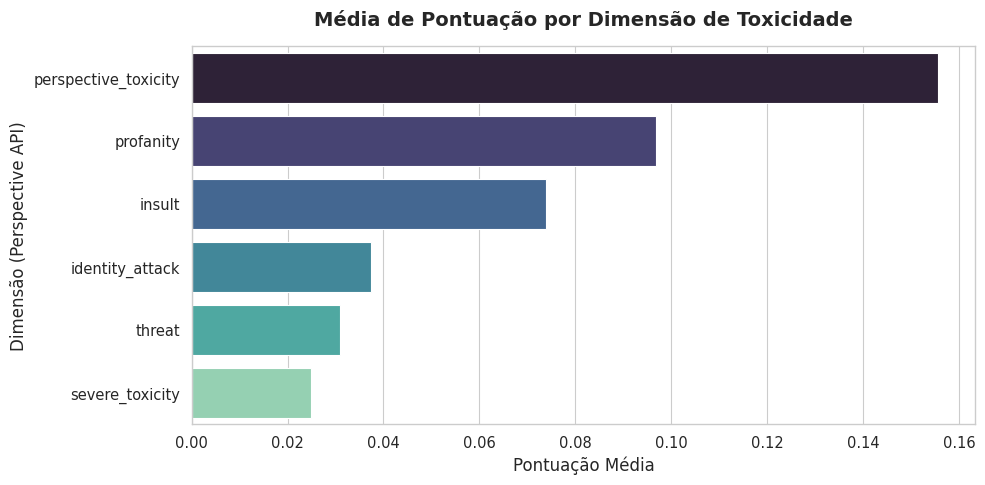

--------------------------------------------------


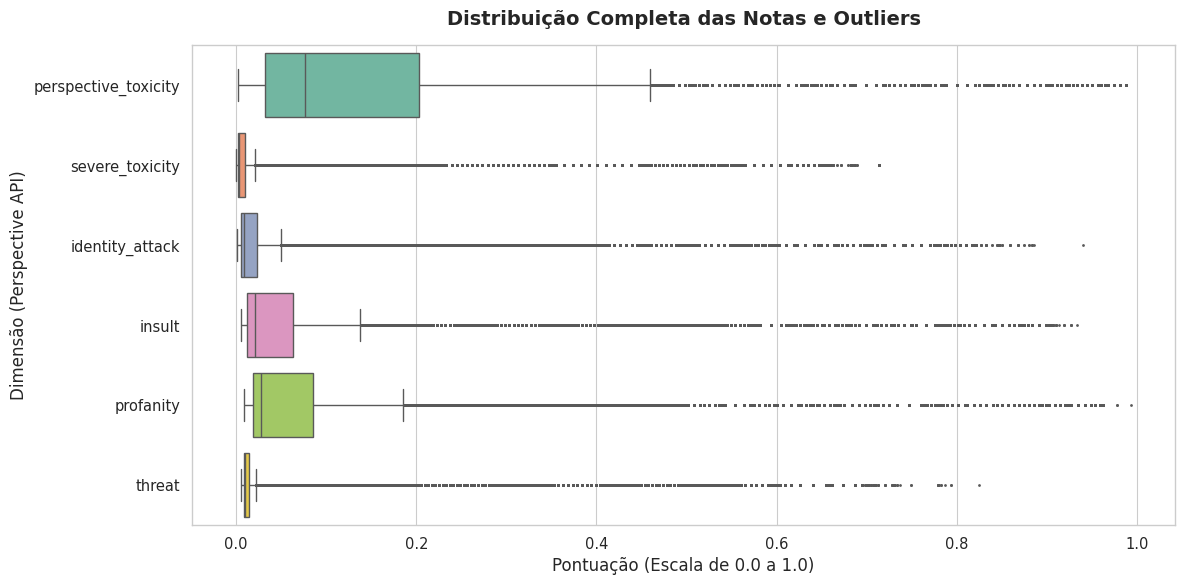

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# ==========================================
# 1. SETUP E CARREGAMENTO
# ==========================================
# Apontando para a raiz do projeto (ajuste se o notebook estiver em subpasta)
raiz_do_projeto = os.path.abspath("") 
if raiz_do_projeto not in sys.path:
    sys.path.append(raiz_do_projeto)

from src.utils.paths import ROOT
from src.utils.data_loader import load_preprocessed_data

print("⏳ Carregando textos originais...")
df_textos = load_preprocessed_data(only_valid_ids=True, columns=['id', 'text_clean'])

print("⏳ Carregando as notas do Perspective...")
caminho_notas = ROOT / "data" / "processed" / "toxicidade_perspective_COMPLETO.csv"
df_notas = pd.read_csv(caminho_notas)

print("🔄 Cruzando as bases...")
df_final = pd.merge(df_notas, df_textos, on='id', how='left')

# Mantendo apenas os posts com notas válidas para os gráficos
df_final = df_final.dropna(subset=['perspective_toxicity']).copy()
print(f"✅ Base pronta com {len(df_final)} posts válidos!\n")

# ==========================================
# 2. ESTATÍSTICAS DESCRITIVAS
# ==========================================
colunas_notas = [
    'perspective_toxicity', 'severe_toxicity', 'identity_attack', 
    'insult', 'profanity', 'threat'
]

print("-" * 50)
print("📊 ESTATÍSTICAS DOS ATRIBUTOS:")
print("-" * 50)
print(df_final[colunas_notas].describe())
print("\n")

# ==========================================
# 3. GERAÇÃO DOS GRÁFICOS
# ==========================================
# Estilo acadêmico
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Gráfico 1: Barras (A Pirâmide da Agressividade)
plt.figure(figsize=(10, 5))
medias = df_final[colunas_notas].mean().sort_values(ascending=False)
sns.barplot(x=medias.values, y=medias.index, palette="mako")
plt.title('Média de Pontuação por Dimensão de Toxicidade', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Pontuação Média', fontsize=12)
plt.ylabel('Dimensão (Perspective API)', fontsize=12)
plt.tight_layout()
plt.show()

print("-" * 50)

# Gráfico 2: Boxplot (Distribuição e Outliers)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_final[colunas_notas], orient='h', palette="Set2", fliersize=1)
plt.title('Distribuição Completa das Notas e Outliers', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Pontuação (Escala de 0.0 a 1.0)', fontsize=12)
plt.ylabel('Dimensão (Perspective API)', fontsize=12)
plt.tight_layout()
plt.show()

# Analise Temporal

In [2]:
import sys
import os
import pyarrow.parquet as pq

# Aponta para a raiz
raiz_do_projeto = os.path.abspath("")
if raiz_do_projeto not in sys.path:
    sys.path.append(raiz_do_projeto)
    
from src.utils.paths import ROOT

caminho_parquet = ROOT / "data" / "processed" / "preprocess_text.parquet"

# Lê apenas os nomes das colunas
colunas_reais = pq.ParquetFile(caminho_parquet).schema.names

print("🔍 Colunas disponíveis no seu Parquet:")
for col in colunas_reais:
    print(f" -> {col}")

🔍 Colunas disponíveis no seu Parquet:
 -> id
 -> text
 -> text_clean
 -> subreddit
 -> depth


⏳ Carregando informações de profundidade e comunidade...


/tmp/ipykernel_431561/2014181157.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_profundidade, x='depth', y='perspective_toxicity', palette='viridis', errorbar=None)


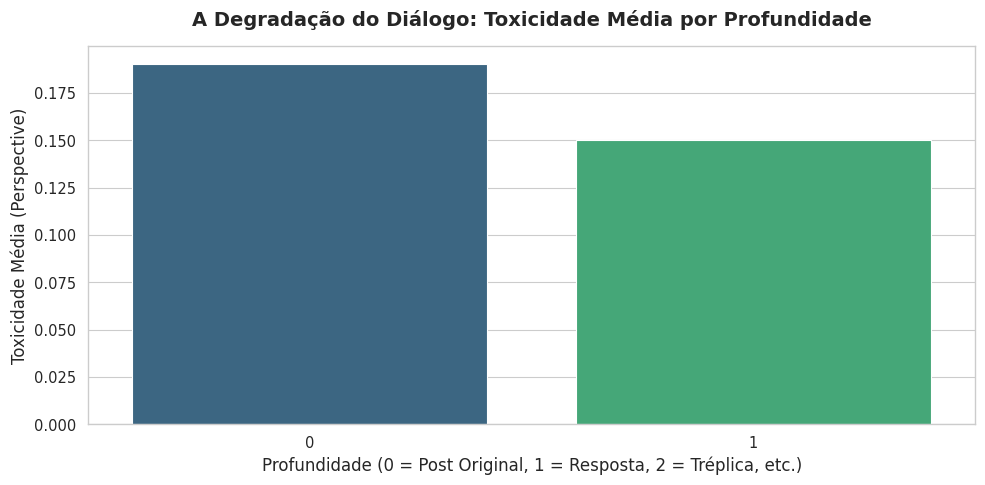

--------------------------------------------------


/tmp/ipykernel_431561/2014181157.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_exploracao, x='subreddit', y='perspective_toxicity', order=ordem_sub, palette='magma', errorbar=None)


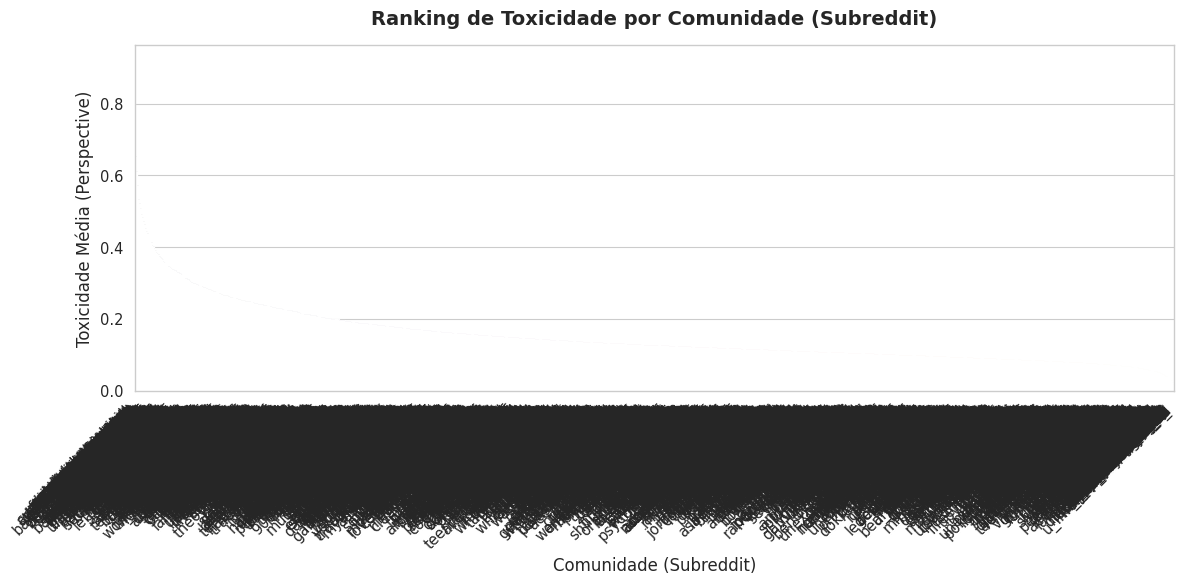

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Carregando as colunas que REALMENTE existem no seu Parquet
print("⏳ Carregando informações de profundidade e comunidade...")
df_infos = load_preprocessed_data(only_valid_ids=True, columns=['id', 'subreddit', 'depth'])

# 2. Juntando essas informações com as notas que já temos na memória
df_exploracao = pd.merge(df_final, df_infos, on='id', how='inner')

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# ==========================================
# GRÁFICO 1: TOXICIDADE POR PROFUNDIDADE
# ==========================================
# Vamos limitar a profundidade até 10 para o gráfico não ficar esmagado
# (discussões com mais de 10 níveis de respostas são raras)
plt.figure(figsize=(10, 5))

df_profundidade = df_exploracao[df_exploracao['depth'] <= 10]
sns.barplot(data=df_profundidade, x='depth', y='perspective_toxicity', palette='viridis', errorbar=None)

plt.title('A Degradação do Diálogo: Toxicidade Média por Profundidade', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Profundidade (0 = Post Original, 1 = Resposta, 2 = Tréplica, etc.)', fontsize=12)
plt.ylabel('Toxicidade Média (Perspective)', fontsize=12)
plt.tight_layout()
plt.show()

print("-" * 50)

# ==========================================
# GRÁFICO 2: RANKING DOS SUBREDDITS
# ==========================================
plt.figure(figsize=(12, 6))

# Calculando a média para ordenar do mais tóxico para o mais pacífico
ordem_sub = df_exploracao.groupby('subreddit')['perspective_toxicity'].mean().sort_values(ascending=False).index

sns.barplot(data=df_exploracao, x='subreddit', y='perspective_toxicity', order=ordem_sub, palette='magma', errorbar=None)

plt.title('Ranking de Toxicidade por Comunidade (Subreddit)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Comunidade (Subreddit)', fontsize=12)
plt.ylabel('Toxicidade Média (Perspective)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Inclina os nomes para caberem bem
plt.tight_layout()
plt.show()

/tmp/ipykernel_431561/4112270426.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_toxicos.index, y=top_15_toxicos.values, palette='magma')


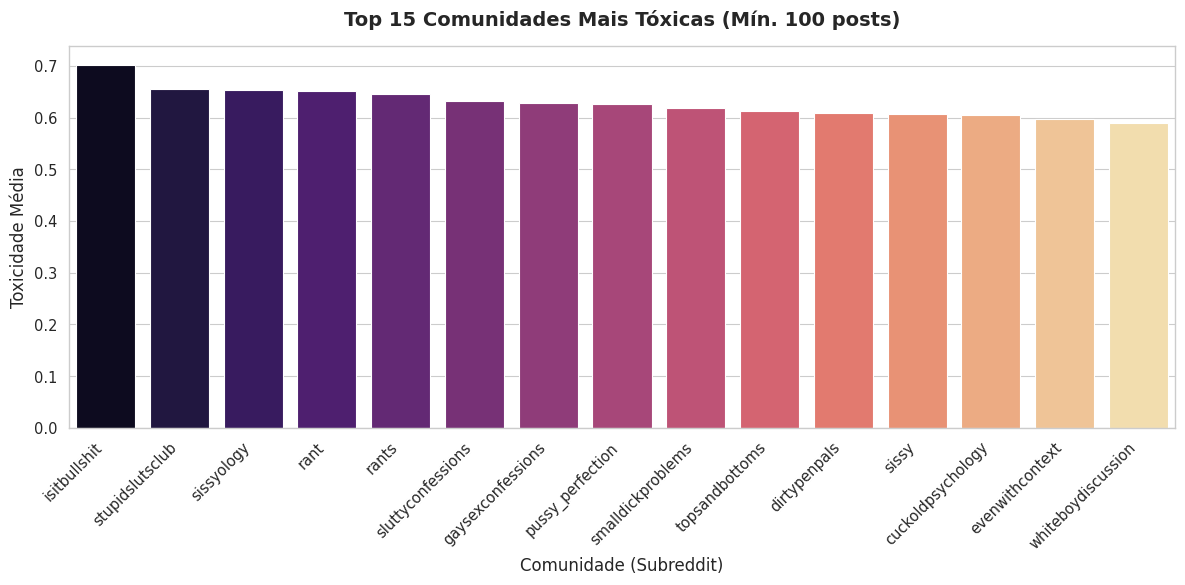

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# 1. Conta quantos posts cada subreddit tem
contagem_subs = df_exploracao['subreddit'].value_counts()

# 2. Mantém apenas os subreddits com 100 posts ou mais (evita anomalias estatísticas)
subs_validos = contagem_subs[contagem_subs >= 100].index
df_subs_filtrado = df_exploracao[df_exploracao['subreddit'].isin(subs_validos)]

# 3. Calcula a média e pega apenas o TOP 15 mais tóxicos
top_15_toxicos = df_subs_filtrado.groupby('subreddit')['perspective_toxicity'].mean().sort_values(ascending=False).head(15)

# 4. Gera o gráfico limpo
sns.barplot(x=top_15_toxicos.index, y=top_15_toxicos.values, palette='magma')

plt.title('Top 15 Comunidades Mais Tóxicas (Mín. 100 posts)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Comunidade (Subreddit)', fontsize=12)
plt.ylabel('Toxicidade Média', fontsize=12)
plt.xticks(rotation=45, ha='right') 

plt.tight_layout()
plt.show()